In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Bootstrap Confidence Intervals

## Objective

Previous notebooks demonstrated that delivery performance influences customer satisfaction using both frequentist and Bayesian approaches.

This notebook introduces Bootstrap Resampling.

Bootstrap allows uncertainty estimation directly from observed data without relying on strong distributional assumptions.

Business Question:

How certain are we that improving delivery performance increases customer satisfaction?

# 1. Imports

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.max_columns", None)

# 2. Load Data

In [2]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")

master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,...,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,...,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,...,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,...,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,...,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


# Create Control and Treatment Groups

Control = Slow Deliveries

Treatment = Fast Deliveries

In [4]:
control = master.loc[master["delivery_speed_group"] == "slow","review_score"].dropna()

treatment = master.loc[master["delivery_speed_group"] == "fast","review_score"].dropna()

print("Control:", len(control))
print("Treatment:", len(treatment))

Control: 54582
Treatment: 54787


# 4. Observed Lift

In [5]:
observed_lift = (treatment.mean()-control.mean())

print(f"Observed Lift: {observed_lift:.4f}")

Observed Lift: 0.4375


How uncertain is this estimate?

# 5. Bootstrap Resampling

Generate thousands of alternative samples from observed data.

Each sample estimates a possible treatment effect.

In [6]:
n_bootstrap = 10000

bootstrap_lifts = []

for _ in range(n_bootstrap):

    control_sample = np.random.choice(control,size=len(control),replace=True)

    treatment_sample = np.random.choice(treatment,size=len(treatment),replace=True)

    lift = (treatment_sample.mean()-control_sample.mean())

    bootstrap_lifts.append(lift)

bootstrap_lifts = np.array(bootstrap_lifts)

# 6. Bootstrap Distribution

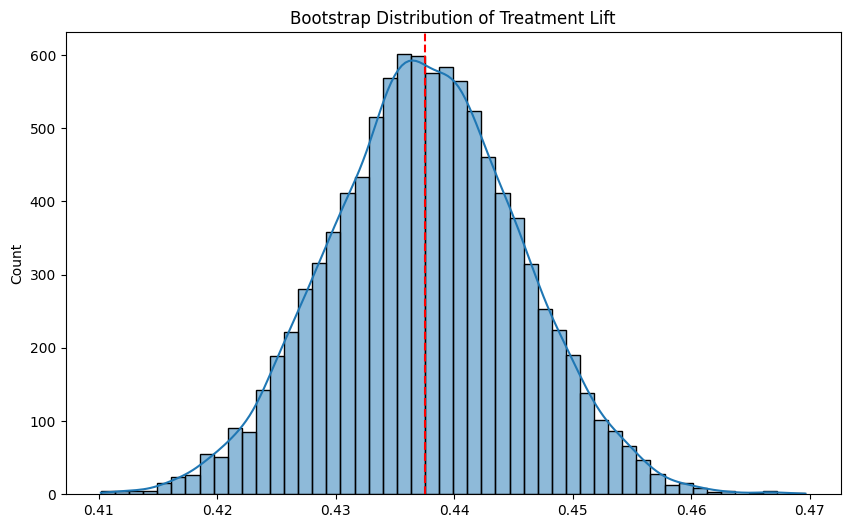

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(bootstrap_lifts,bins=50,kde=True)

plt.axvline(observed_lift,color="red",linestyle="--")

plt.title( "Bootstrap Distribution of Treatment Lift")

plt.show()

# 7. Bootstrap Confidence Interval

In [8]:
lower = np.percentile(bootstrap_lifts,2.5)

upper = np.percentile(bootstrap_lifts,97.5)

print(f"95% Bootstrap CI: ({lower:.4f}, {upper:.4f})")

95% Bootstrap CI: (0.4217, 0.4535)


Most plausible lifts  fall inside this range.

# 8. Probability Lift > 0

In [9]:
prob_positive = np.mean(bootstrap_lifts > 0)

print(f"P(Lift > 0): {prob_positive:.4%}")

P(Lift > 0): 100.0000%


Every bootstrap experiment showed positive lift.

#  9. Bootstrap Effect Size
Distribution of Cohen's d

In [10]:
effect_sizes = []

for _ in range(5000):

    c = np.random.choice(control,len(control),replace=True)

    t = np.random.choice(treatment,len(treatment),replace=True)

    pooled_std = np.sqrt((c.var()+t.var()) / 2)

    d = (t.mean()-c.mean()) / pooled_std

    effect_sizes.append(d)

effect_sizes = np.array(effect_sizes)

print("Bootstrap Cohen's d Mean:",effect_sizes.mean())

Bootstrap Cohen's d Mean: 0.3291425262599543


# Bootstrap Analysis Summary

Bootstrap resampling was used to estimate uncertainty directly from observed data without relying on strong distributional assumptions.

A total of 10,000 bootstrap experiments were simulated.

Key Results:

- Observed Lift = +0.438 Review Points
- 95% Bootstrap Confidence Interval = (0.422, 0.454)
- Probability Lift > 0 = 100%
- Bootstrap Cohen's d = 0.329

The bootstrap distribution remains entirely above zero, indicating strong evidence that faster deliveries improve customer satisfaction.

Importantly, the bootstrap results closely match both the frequentist and Bayesian analyses conducted in previous notebooks. This consistency across multiple statistical frameworks increases confidence that the observed relationship is genuine rather than an artifact of modeling assumptions.

From a business perspective, the results provide strong evidence that delivery performance improvements are likely to generate measurable gains in customer satisfaction.